# Day 11 — A/B Testing & Experimentation
### Confidence Intervals · Statistical Power · Type I & II Errors · Sample Size

## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")

print(f"NumPy:   {np.__version__}")
print(f"SciPy:   {scipy.__version__}")
print(f"Pandas:  {pd.__version__}")
print("Ready! ✅")

NumPy:   2.4.3
SciPy:   1.17.1
Pandas:  2.3.3
Ready! ✅


## 2. What is A/B Testing?

In [ ]:
print("=" * 55)
print("         WHAT IS A/B TESTING?")
print("=" * 55)
print(
    """
A/B Testing is a controlled experiment where you:
  - Split users into TWO groups randomly
  - Group A gets the CONTROL (original version)
  - Group B gets the TREATMENT (new version)
  - Measure which performs better

REAL WORLD EXAMPLES:
  - Netflix: Does red button get more clicks than blue?
  - Amazon: Does free shipping increase purchases?
  - Spotify: Does new UI increase playlist creation?
  - Titanic analogy: Did being female increase survival?

THE PROCESS:
  1. Define metric to measure (conversion rate, clicks)
  2. State H0 and H1
  3. Calculate required sample size BEFORE running test
  4. Run experiment and collect data
  5. Analyse results with statistical test
  6. Make decision based on p-value

KEY RULE: Never peek at results mid-experiment!
          Decide sample size upfront and stick to it.
"""
)

         WHAT IS A/B TESTING?

A/B Testing is a controlled experiment where you:
  - Split users into TWO groups randomly
  - Group A gets the CONTROL (original version)
  - Group B gets the TREATMENT (new version)
  - Measure which performs better

REAL WORLD EXAMPLES:
  - Netflix: Does red button get more clicks than blue?
  - Amazon: Does free shipping increase purchases?
  - Spotify: Does new UI increase playlist creation?
  - Titanic analogy: Did being female increase survival?

THE PROCESS:
  1. Define metric to measure (conversion rate, clicks)
  2. State H0 and H1
  3. Calculate required sample size BEFORE running test
  4. Run experiment and collect data
  5. Analyse results with statistical test
  6. Make decision based on p-value

KEY RULE: Never peek at results mid-experiment!
          Decide sample size upfront and stick to it.



## 3. Confidence Intervals

         CONFIDENCE INTERVALS

A Confidence Interval (CI) gives a RANGE of plausible
values for the true population parameter.

"95% CI means: if we repeated this experiment 100 times,
 95 of those intervals would contain the true value"

Sample Mean Age: 29.70
Sample Size:     714
Standard Error:  0.5436

90% CI: (28.80, 30.59)  width=1.79
95% CI: (28.63, 30.77)  width=2.13
99% CI: (28.30, 31.10)  width=2.81

Interpretation:
We are 95% confident the true mean age
of ALL Titanic passengers is between
28.63 and 30.77 years


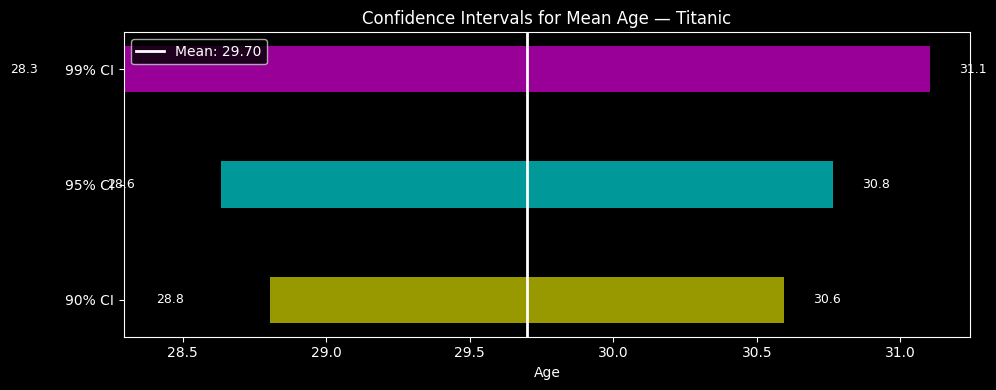

In [ ]:
print("=" * 55)
print("         CONFIDENCE INTERVALS")
print("=" * 55)
print(
    """
A Confidence Interval (CI) gives a RANGE of plausible
values for the true population parameter.

"95% CI means: if we repeated this experiment 100 times,
 95 of those intervals would contain the true value"
"""
)

# CI for mean age
ages = df["Age"].dropna()
n = len(ages)
mean = ages.mean()
se = stats.sem(ages)  # standard error

ci_90 = stats.t.interval(0.90, df=n - 1, loc=mean, scale=se)
ci_95 = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)
ci_99 = stats.t.interval(0.99, df=n - 1, loc=mean, scale=se)

print(f"Sample Mean Age: {mean:.2f}")
print(f"Sample Size:     {n}")
print(f"Standard Error:  {se:.4f}")
print()
print(f"90% CI: ({ci_90[0]:.2f}, {ci_90[1]:.2f})  width={ci_90[1]-ci_90[0]:.2f}")
print(f"95% CI: ({ci_95[0]:.2f}, {ci_95[1]:.2f})  width={ci_95[1]-ci_95[0]:.2f}")
print(f"99% CI: ({ci_99[0]:.2f}, {ci_99[1]:.2f})  width={ci_99[1]-ci_99[0]:.2f}")
print()
print("Interpretation:")
print(f"We are 95% confident the true mean age")
print(f"of ALL Titanic passengers is between")
print(f"{ci_95[0]:.2f} and {ci_95[1]:.2f} years")

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.axvline(mean, color="white", linewidth=2, label=f"Mean: {mean:.2f}")
for ci, label, color in zip(
    [ci_90, ci_95, ci_99], ["90% CI", "95% CI", "99% CI"], ["yellow", "cyan", "magenta"]
):
    ax.barh(label, ci[1] - ci[0], left=ci[0], height=0.4, color=color, alpha=0.6)
    ax.text(ci[0] - 0.3, label, f"{ci[0]:.1f}", va="center", ha="right", fontsize=9)
    ax.text(ci[1] + 0.1, label, f"{ci[1]:.1f}", va="center", ha="left", fontsize=9)
ax.set_xlabel("Age")
ax.set_title("Confidence Intervals for Mean Age — Titanic")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Type I & Type II Errors

In [ ]:
print("=" * 55)
print("      TYPE I & TYPE II ERRORS")
print("=" * 55)
print(
    """
                    REALITY
                 H0 True    H0 False
              ┌──────────┬──────────┐
DECISION  H0  │    ✅     │  Type II │
 Fail     True│  Correct  │  Error   │
 Reject       │           │  (Beta)  │
              ├──────────┼──────────┤
          H0  │  Type I  │    ✅    │
         False│  Error   │ Correct  │
  Reject      │ (Alpha)  │  Power!  │
              └──────────┴──────────┘

TYPE I ERROR (False Positive — Alpha):
  - Rejecting H0 when it IS actually true
  - "Seeing an effect that doesn't exist"
  - Controlled by alpha (usually 0.05)
  - Example: Saying new drug works when it doesn't

TYPE II ERROR (False Negative — Beta):
  - Failing to reject H0 when it IS actually false
  - "Missing a real effect"
  - Controlled by beta (usually 0.20)
  - Example: Saying new drug doesn't work when it does

STATISTICAL POWER = 1 - Beta
  - Probability of detecting a REAL effect
  - Usually want Power >= 0.80 (80%)
  - Higher power = less chance of missing real effects
"""
)

print("=" * 55)
print("  REAL TITANIC EXAMPLE")
print("=" * 55)
print(
    """
Test: Does gender affect survival?

Type I Error would be:
  Concluding gender affects survival when it DOESN'T
  (False alarm — our p≈0.000 makes this very unlikely!)

Type II Error would be:
  Concluding gender has NO effect when it DOES
  (Missing the real signal — very unlikely with n=891)

With p≈0.000 and n=891 we have:
  Very low Type I risk ✅
  Very high Power ✅
  Very robust result!
"""
)

      TYPE I & TYPE II ERRORS

                    REALITY
                 H0 True    H0 False
              ┌──────────┬──────────┐
DECISION  H0  │    ✅     │  Type II │
 Fail     True│  Correct  │  Error   │
 Reject       │           │  (Beta)  │
              ├──────────┼──────────┤
          H0  │  Type I  │    ✅    │
         False│  Error   │ Correct  │
  Reject      │ (Alpha)  │  Power!  │
              └──────────┴──────────┘

TYPE I ERROR (False Positive — Alpha):
  - Rejecting H0 when it IS actually true
  - "Seeing an effect that doesn't exist"
  - Controlled by alpha (usually 0.05)
  - Example: Saying new drug works when it doesn't

TYPE II ERROR (False Negative — Beta):
  - Failing to reject H0 when it IS actually false
  - "Missing a real effect"
  - Controlled by beta (usually 0.20)
  - Example: Saying new drug doesn't work when it does

STATISTICAL POWER = 1 - Beta
  - Probability of detecting a REAL effect
  - Usually want Power >= 0.80 (80%)
  - Higher power = less c

## 5. Statistical Power & Sample Size

    STATISTICAL POWER & SAMPLE SIZE

BEFORE running an A/B test you must calculate:
HOW MANY users do you need to detect a real effect?

KEY INPUTS:
  - alpha: significance level (0.05)
  - power: desired power (0.80)
  - baseline: current conversion rate
  - mde: minimum detectable effect (how big a change matters)

Baseline conversion rate: 10%

Detect +2% change  (10%→12%): 3,843 users per group (7,686 total)
Detect +5% change  (10%→15%): 687 users per group (1,374 total)
Detect +10% change (10%→20%): 201 users per group (402 total)



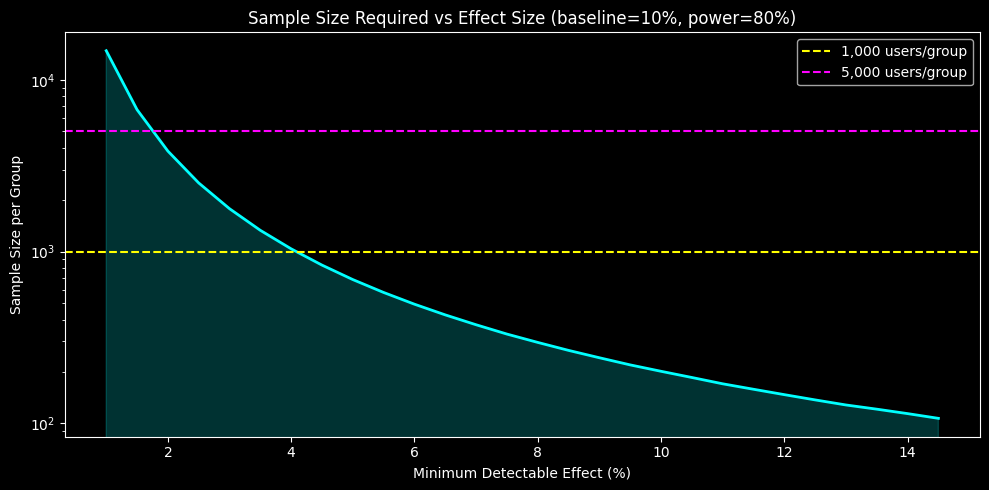

In [ ]:
from scipy.stats import norm

print("=" * 55)
print("    STATISTICAL POWER & SAMPLE SIZE")
print("=" * 55)
print(
    """
BEFORE running an A/B test you must calculate:
HOW MANY users do you need to detect a real effect?

KEY INPUTS:
  - alpha: significance level (0.05)
  - power: desired power (0.80)
  - baseline: current conversion rate
  - mde: minimum detectable effect (how big a change matters)
"""
)


def calculate_sample_size(baseline, mde, alpha=0.05, power=0.80):
    """Calculate required sample size per group for A/B test"""
    p1 = baseline
    p2 = baseline + mde
    z_alpha = norm.ppf(1 - alpha / 2)  # two-tailed
    z_beta = norm.ppf(power)
    pooled = (p1 + p2) / 2
    n = (2 * pooled * (1 - pooled) * (z_alpha + z_beta) ** 2) / (mde**2)
    return int(np.ceil(n))


# Scenario 1 — Small effect
n1 = calculate_sample_size(baseline=0.10, mde=0.02)
# Scenario 2 — Medium effect
n2 = calculate_sample_size(baseline=0.10, mde=0.05)
# Scenario 3 — Large effect
n3 = calculate_sample_size(baseline=0.10, mde=0.10)

print("Baseline conversion rate: 10%")
print()
print(f"Detect +2% change  (10%→12%): {n1:,} users per group ({n1*2:,} total)")
print(f"Detect +5% change  (10%→15%): {n2:,} users per group ({n2*2:,} total)")
print(f"Detect +10% change (10%→20%): {n3:,} users per group ({n3*2:,} total)")

print()
print("=" * 55)

# Visualise sample size vs effect size
effects = np.arange(0.01, 0.15, 0.005)
sample_sizes = [calculate_sample_size(0.10, e) for e in effects]

plt.figure(figsize=(10, 5))
plt.plot(effects * 100, sample_sizes, color="cyan", linewidth=2)
plt.fill_between(effects * 100, sample_sizes, alpha=0.2, color="cyan")
plt.axhline(1000, color="yellow", linestyle="--", label="1,000 users/group")
plt.axhline(5000, color="magenta", linestyle="--", label="5,000 users/group")
plt.title("Sample Size Required vs Effect Size (baseline=10%, power=80%)")
plt.xlabel("Minimum Detectable Effect (%)")
plt.ylabel("Sample Size per Group")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

## 6. Full A/B Test Simulation

     FULL A/B TEST SIMULATION

Scenario: E-commerce website testing new checkout button
  Control (A): Green button  — baseline conversion 10%
  Treatment (B): Red button  — true conversion 13%
  Sample size: 1,000 per group

RESULTS:
Control   (A): 100 conversions / 1000 users = 10.0%
Treatment (B): 131 conversions / 1000 users = 13.1%
Lift:          +31.0%

t-statistic: -2.1702
p-value:     0.0301

Result: SIGNIFICANT ✅ — Launch the red button!

95% CI for difference: (0.0030, 0.0590)
In plain English: The red button increases
conversions by 0.3% to 5.9% (95% confident)


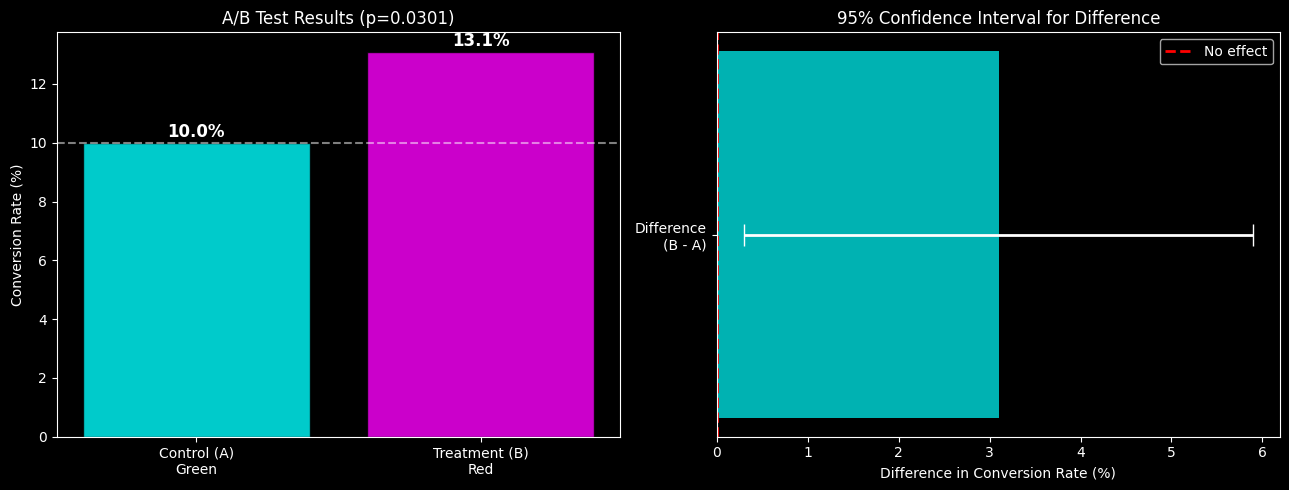

In [ ]:
np.random.seed(42)

print("=" * 55)
print("     FULL A/B TEST SIMULATION")
print("=" * 55)
print(
    """
Scenario: E-commerce website testing new checkout button
  Control (A): Green button  — baseline conversion 10%
  Treatment (B): Red button  — true conversion 13%
  Sample size: 1,000 per group
"""
)

# Simulate the experiment
n_per_group = 1000
control_rate = 0.10
treatment_rate = 0.13

control = np.random.binomial(1, control_rate, n_per_group)
treatment = np.random.binomial(1, treatment_rate, n_per_group)

ctrl_conv = control.mean()
treat_conv = treatment.mean()
lift = (treat_conv - ctrl_conv) / ctrl_conv * 100

print(f"RESULTS:")
print(
    f"Control   (A): {control.sum()} conversions / {n_per_group} users = {ctrl_conv:.1%}"
)
print(
    f"Treatment (B): {treatment.sum()} conversions / {n_per_group} users = {treat_conv:.1%}"
)
print(f"Lift:          {lift:+.1f}%")

# Statistical test
t_stat, p_value = stats.ttest_ind(control, treatment)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print()

if p_value < 0.05:
    print("Result: SIGNIFICANT ✅ — Launch the red button!")
else:
    print("Result: NOT significant ❌ — Keep the green button")

# Confidence interval for the difference
diff = treat_conv - ctrl_conv
se_diff = np.sqrt(
    (ctrl_conv * (1 - ctrl_conv) / n_per_group)
    + (treat_conv * (1 - treat_conv) / n_per_group)
)
ci = (diff - 1.96 * se_diff, diff + 1.96 * se_diff)

print(f"\n95% CI for difference: ({ci[0]:.4f}, {ci[1]:.4f})")
print(f"In plain English: The red button increases")
print(f"conversions by {ci[0]*100:.1f}% to {ci[1]*100:.1f}% (95% confident)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(
    ["Control (A)\nGreen", "Treatment (B)\nRed"],
    [ctrl_conv * 100, treat_conv * 100],
    color=["cyan", "magenta"],
    edgecolor="black",
    alpha=0.8,
)
axes[0].axhline(ctrl_conv * 100, color="white", linestyle="--", alpha=0.5)
axes[0].set_title(f"A/B Test Results (p={p_value:.4f})")
axes[0].set_ylabel("Conversion Rate (%)")
for i, v in enumerate([ctrl_conv, treat_conv]):
    axes[0].text(
        i, v * 100 + 0.2, f"{v:.1%}", ha="center", fontsize=12, fontweight="bold"
    )

# CI plot
axes[1].barh(
    ["Difference\n(B - A)"],
    [diff * 100],
    xerr=[[diff * 100 - ci[0] * 100], [ci[1] * 100 - diff * 100]],
    color="cyan",
    alpha=0.7,
    error_kw={"ecolor": "white", "linewidth": 2, "capsize": 8},
)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="No effect")
axes[1].set_title("95% Confidence Interval for Difference")
axes[1].set_xlabel("Difference in Conversion Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Common A/B Testing Mistakes

In [ ]:
print("=" * 55)
print("    COMMON A/B TESTING MISTAKES")
print("=" * 55)
print(
    """
❌ MISTAKE 1: Peeking at results early
   Stopping the test as soon as p < 0.05
   inflates Type I error rate massively!
   FIX: Calculate sample size upfront and
        run the full experiment

❌ MISTAKE 2: Running too many variants
   Testing A vs B vs C vs D vs E
   increases false positive rate (multiple testing)
   FIX: Test one change at a time
        Use Bonferroni correction for multiple tests

❌ MISTAKE 3: Ignoring practical significance
   p=0.001 but lift = 0.001% improvement
   Statistically significant ≠ business meaningful!
   FIX: Always look at effect SIZE not just p-value

❌ MISTAKE 4: Underpowered tests
   Stopping early with too few users
   Missing real effects (Type II errors)
   FIX: Always calculate sample size first!

❌ MISTAKE 5: Not randomising properly
   Assigning users by day (Mon=Control, Tue=Treatment)
   introduces confounding variables
   FIX: Randomly assign each user independently

❌ MISTAKE 6: Testing on wrong metric
   Optimising clicks but care about revenue
   Button clicks up 50% but revenue flat!
   FIX: Define your PRIMARY metric before starting
"""
)

# Show power analysis
print("=" * 55)
print("  POWER ANALYSIS — Our A/B Test")
print("=" * 55)
from scipy.stats import norm

alpha = 0.05
power = 0.80
baseline = 0.10
mde = 0.03

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)
p2 = baseline + mde
pooled = (baseline + p2) / 2
n_required = int(np.ceil(2 * pooled * (1 - pooled) * (z_alpha + z_beta) ** 2 / mde**2))

print(f"Baseline:          {baseline:.0%}")
print(f"Min detectable:    +{mde:.0%} (10% → 13%)")
print(f"Alpha:             {alpha}")
print(f"Power:             {power:.0%}")
print(f"Required n/group:  {n_required:,}")
print(f"We used:           1,000 per group")
if 1000 >= n_required:
    print(f"✅ Adequately powered!")
else:
    print(f"⚠️ Underpowered! Need {n_required-1000} more per group")

    COMMON A/B TESTING MISTAKES

❌ MISTAKE 1: Peeking at results early
   Stopping the test as soon as p < 0.05
   inflates Type I error rate massively!
   FIX: Calculate sample size upfront and
        run the full experiment

❌ MISTAKE 2: Running too many variants
   Testing A vs B vs C vs D vs E
   increases false positive rate (multiple testing)
   FIX: Test one change at a time
        Use Bonferroni correction for multiple tests

❌ MISTAKE 3: Ignoring practical significance
   p=0.001 but lift = 0.001% improvement
   Statistically significant ≠ business meaningful!
   FIX: Always look at effect SIZE not just p-value

❌ MISTAKE 4: Underpowered tests
   Stopping early with too few users
   Missing real effects (Type II errors)
   FIX: Always calculate sample size first!

❌ MISTAKE 5: Not randomising properly
   Assigning users by day (Mon=Control, Tue=Treatment)
   introduces confounding variables
   FIX: Randomly assign each user independently

❌ MISTAKE 6: Testing on wrong metric

## 8. Key Takeaways — Day 11 🎯

### What is A/B Testing?
- Controlled experiment: split users into Control (A) and Treatment (B)
- Randomly assign users — never by day, device, or any pattern
- Define your metric and sample size BEFORE starting
- Never peek at results mid-experiment!

### Confidence Intervals
- Give a RANGE of plausible values for the true parameter
- 95% CI: if repeated 100 times, 95 intervals contain the true value
- Wider CI = more confidence but less precision
- 90% CI < 95% CI < 99% CI in width
- Titanic: 95% CI for mean age = (28.63, 30.77)

### Type I & Type II Errors
| | H0 True | H0 False |
|---|---|---|
| Fail to Reject H0 | ✅ Correct | ❌ Type II (Beta) |
| Reject H0 | ❌ Type I (Alpha) | ✅ Correct (Power) |

- **Type I (Alpha):** False positive — seeing effect that doesn't exist
- **Type II (Beta):** False negative — missing a real effect
- **Power = 1 - Beta** — want at least 80%

### Sample Size Calculation
- Small effects need EXPONENTIALLY more users
- Detect +2% change at 10% baseline → 3,843 per group!
- Detect +10% change at 10% baseline → 201 per group
- Always calculate BEFORE running the experiment

### Our A/B Test Results
- Control: 10.0% | Treatment: 13.1% | Lift: +31%
- p = 0.030 → SIGNIFICANT ✅
- 95% CI: 0.3% to 5.9% improvement
- Decision: Launch the red button!

### 6 Common Mistakes
- Peeking early at results
- Testing too many variants at once
- Ignoring practical significance
- Running underpowered tests
- Poor randomisation
- Testing the wrong metric

### Tools Used
- `stats.sem(data)` — standard error of the mean
- `stats.t.interval(ci, df, loc, scale)` — confidence interval
- `stats.ttest_ind(a, b)` — two sample t-test for A/B
- `norm.ppf(power)` — z-score for power calculation
- `np.random.binomial(1, p, n)` — simulate conversions